In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('world_population_data.csv')
df.head()

,rank,cca3,country,continent,2023 population,2022 population,2020 population,2015 population,2010 population,2000 population,1990 population,1980 population,1970 population,area (km²),density (km²),growth rate,world percentage
0,1,IND,India,Asia,1428627663,1417173173,1396387127,1322866505,1240613620,1059633675,870452165,696828385,557501301,3287590.0,481,0.81%,17.85%
1,2,CHN,China,Asia,1425671352,1425887337,1424929781,1393715448,1348191368,1264099069,1153704252,982372466,822534450,9706961.0,151,-0.02%,17.81%
2,3,USA,United States,North America,339996563,338289857,335942003,324607776,311182845,282398554,248083732,223140018,200328340,9372610.0,37,0.50%,4.25%
3,4,IDN,Indonesia,Asia,277534122,275501339,271857970,259091970,244016173,214072421,182159874,148177096,115228394,1904569.0,148,0.74%,3.47%
4,5,PAK,Pakistan,Asia,240485658,235824862,227196741,210969298,194454498,154369924,115414069,80624057,59290872,881912.0,312,1.98%,3.00%


In [3]:
df.shape

(234, 17)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rank              234 non-null    int64  
 1   cca3              234 non-null    str    
 2   country           234 non-null    str    
 3   continent         234 non-null    str    
 4   2023 population   234 non-null    int64  
 5   2022 population   234 non-null    int64  
 6   2020 population   234 non-null    int64  
 7   2015 population   234 non-null    int64  
 8   2010 population   234 non-null    int64  
 9   2000 population   234 non-null    int64  
 10  1990 population   234 non-null    int64  
 11  1980 population   234 non-null    int64  
 12  1970 population   234 non-null    int64  
 13  area (km²)        234 non-null    float64
 14  density (km²)     234 non-null    int64  
 15  growth rate       234 non-null    str    
 16  world percentage  234 non-null    str    
dtypes: float

In [5]:
df.isna().sum()

,0
rank,0
cca3,0
country,0
continent,0
2023 population,0
2022 population,0
2020 population,0
2015 population,0
2010 population,0
2000 population,0


In [6]:
df.describe()

,rank,2023 population,2022 population,2020 population,2015 population,2010 population,2000 population,1990 population,1980 population,1970 population,area (km²),density (km²)
count,234.000000,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,234.000000
mean,117.500000,3.437442e+07,3.407441e+07,3.350107e+07,3.172996e+07,2.984524e+07,2.626947e+07,2.271022e+07,1.898462e+07,1.578691e+07,5.814500e+05,451.282051
std,67.694165,1.373864e+08,1.367664e+08,1.355899e+08,1.304050e+08,1.242185e+08,1.116982e+08,9.783217e+07,8.178519e+07,6.779509e+07,1.761841e+06,1979.398922
min,1.000000,5.180000e+02,5.100000e+02,5.200000e+02,5.640000e+02,5.960000e+02,6.510000e+02,7.000000e+02,7.330000e+02,7.520000e+02,4.400000e-01,0.000000
25%,59.250000,4.225982e+05,4.197385e+05,4.152845e+05,4.046760e+05,3.931490e+05,3.272420e+05,2.641158e+05,2.296142e+05,1.559970e+05,2.650000e+03,39.500000
50%,117.500000,5.643895e+06,5.559944e+06,5.493074e+06,5.307400e+06,4.942770e+06,4.292907e+06,3.825410e+06,3.141146e+06,2.604830e+06,8.119950e+04,97.500000
75%,175.750000,2.324537e+07,2.247650e+07,2.144798e+07,1.973085e+07,1.915957e+07,1.576230e+07,1.186923e+07,9.826054e+06,8.817329e+06,4.304258e+05,242.750000
max,234.000000,1.428628e+09,1.425887e+09,1.424930e+09,1.393715e+09,1.348191e+09,1.264099e+09,1.153704e+09,9.823725e+08,8.225344e+08,1.709824e+07,21403.000000


## Cleaning

In [7]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
df = df.rename(columns={df.columns[13]: 'area', df.columns[14]: 'density'})
df.head(2)

,rank,cca3,country,continent,2023_population,2022_population,2020_population,2015_population,2010_population,2000_population,1990_population,1980_population,1970_population,area,density,growth_rate,world_percentage
0,1,IND,India,Asia,1428627663,1417173173,1396387127,1322866505,1240613620,1059633675,870452165,696828385,557501301,3287590.0,481,0.81%,17.85%
1,2,CHN,China,Asia,1425671352,1425887337,1424929781,1393715448,1348191368,1264099069,1153704252,982372466,822534450,9706961.0,151,-0.02%,17.81%


In [8]:
df['growth_rate'] = df['growth_rate'].str.replace('%', '').astype(float)
df['world_percentage'] = df['world_percentage'].str.replace('%', '').astype(float)

In [9]:
years = ['1970_population', '1980_population', '1990_population', '2000_population', '2010_population', '2015_population', '2020_population', '2022_population', '2023_population']
df['change_since_1970'] = df['2023_population'] - df['1970_population']
df['growth_since_1970'] = df['2023_population'] / df['1970_population']

## Continents

In [10]:
df['continent'].value_counts()

,count
continent,
Africa,57
Asia,50
Europe,50
North America,40
Oceania,23
South America,14


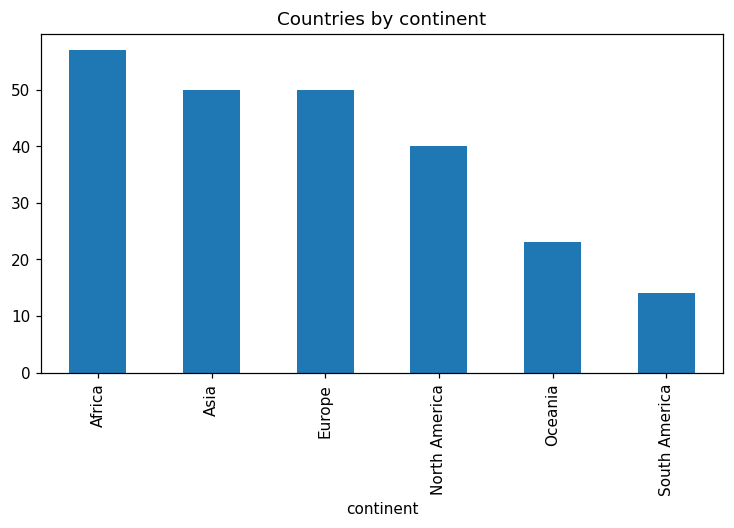

In [11]:
df['continent'].value_counts().plot(kind='bar', figsize=(8,4))
plt.title('Countries by continent')
plt.show()

In [12]:
pop_cont = df.groupby('continent')['2023_population'].sum().sort_values(ascending=False)
pop_cont

,2023_population
continent,
Asia,4751819588
Africa,1460476458
Europe,741869197
North America,604155369
South America,439719009
Oceania,45575769


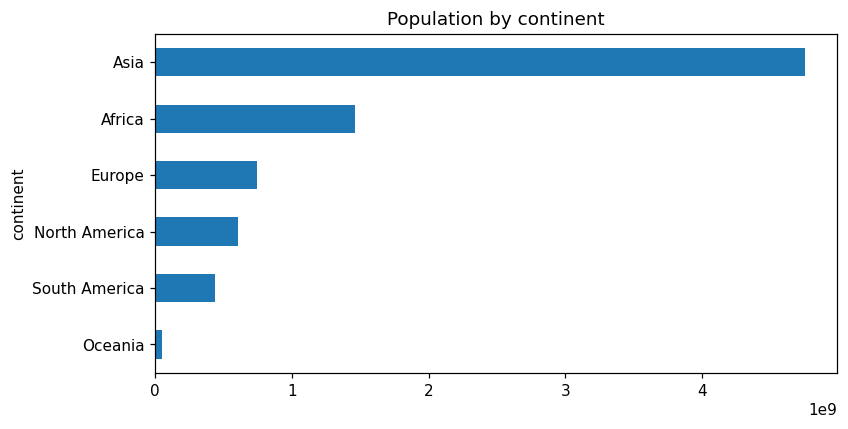

In [13]:
pop_cont.sort_values().plot(kind='barh', figsize=(8,4))
plt.title('Population by continent')
plt.show()

## Countries

In [14]:
df.sort_values('2023_population', ascending=False).head(10)[['country', 'continent', '2023_population', 'world_percentage']]

,country,continent,2023_population,world_percentage
0,India,Asia,1428627663,17.85
1,China,Asia,1425671352,17.81
2,United States,North America,339996563,4.25
3,Indonesia,Asia,277534122,3.47
4,Pakistan,Asia,240485658,3.00
5,Nigeria,Africa,223804632,2.80
6,Brazil,South America,216422446,2.70
7,Bangladesh,Asia,172954319,2.16
8,Russia,Europe,144444359,1.80
9,Mexico,North America,128455567,1.60


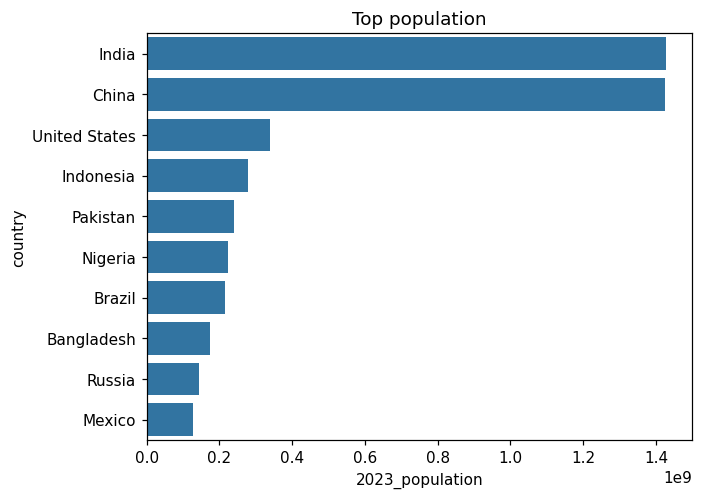

In [15]:
top = df.sort_values('2023_population', ascending=False).head(10)
sns.barplot(data=top, x='2023_population', y='country')
plt.title('Top population')
plt.show()

In [ ]:
df.sort_values('density', ascending=False).head(10)[['country', 'continent', 'density', 'area',      '2023_population']] 

,country,continent,density,area,2023_population
166,Macau,Asia,21403,32.90,704149
216,Monaco,Europe,18149,2.02,36297
113,Singapore,Asia,8377,710.00,6014723
103,Hong Kong,Asia,7135,1104.00,7491609
218,Gibraltar,Europe,4807,6.80,32688
153,Bahrain,Asia,1892,765.00,1485509
173,Maldives,Asia,1737,300.00,521021
172,Malta,Europe,1672,316.00,535064
7,Bangladesh,Asia,1329,147570.00,172954319
212,Sint Maarten,North America,1301,34.00,44222


## Growth

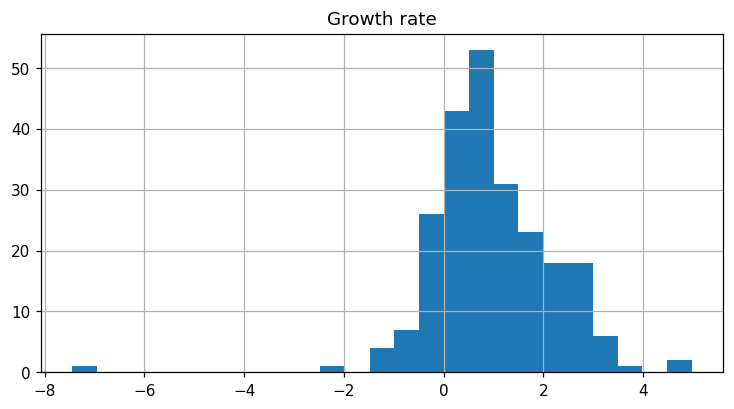

In [17]:
df['growth_rate'].hist(bins=25, figsize=(8,4))
plt.title('Growth rate')
plt.show()

In [18]:
df.sort_values('growth_rate', ascending=False).head(10)[['country', 'continent', 'growth_rate', '2023_population']]

,country,continent,growth_rate,2023_population
59,Syria,Asia,4.98,23227014
133,Moldova,Europe,4.98,3435931
53,Niger,Africa,3.80,27202843
14,DR Congo,Africa,3.29,102262808
66,Chad,Africa,3.13,18278568
57,Mali,Africa,3.10,23293698
68,Somalia,Africa,3.10,18143378
41,Angola,Africa,3.08,36684202
180,Mayotte,Africa,3.03,335995
21,Tanzania,Africa,2.96,67438106


In [19]:
df.sort_values('growth_rate').head(10)[['country', 'continent', 'growth_rate', '2023_population']]

,country,continent,growth_rate,2023_population
40,Ukraine,Europe,-7.45,36744634
121,Lebanon,Asia,-2.47,5353930
109,Bulgaria,Europe,-1.39,6687717
141,Lithuania,Europe,-1.15,2718352
150,Latvia,Europe,-1.10,1830211
104,Serbia,Europe,-1.00,7149077
213,American Samoa,Oceania,-0.81,43914
199,United States Virgin Islands,North America,-0.72,98750
136,Bosnia and Herzegovina,Europe,-0.70,3210847
225,Wallis and Futuna,Oceania,-0.60,11502


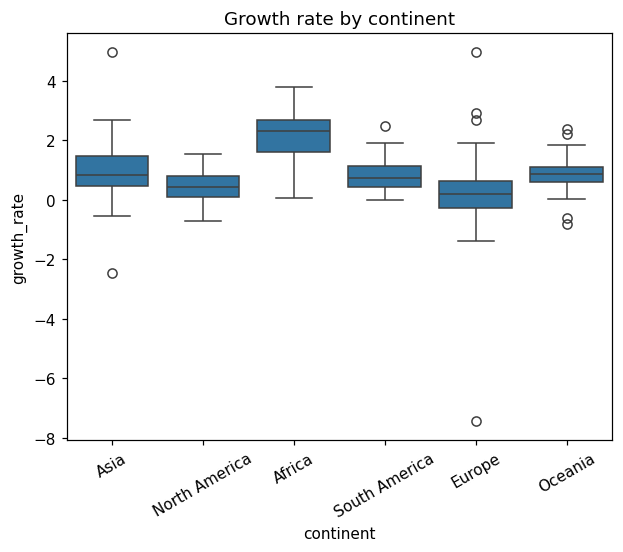

In [20]:
sns.boxplot(data=df, x='continent', y='growth_rate')
plt.xticks(rotation=30)
plt.title('Growth rate by continent')
plt.show()

## Since 1970

In [21]:
df.sort_values('change_since_1970', ascending=False).head(10)[['country', 'continent', '1970_population', '2023_population', 'change_since_1970']]

,country,continent,1970_population,2023_population,change_since_1970
0,India,Asia,557501301,1428627663,871126362
1,China,Asia,822534450,1425671352,603136902
4,Pakistan,Asia,59290872,240485658,181194786
5,Nigeria,Africa,55569264,223804632,168235368
3,Indonesia,Asia,115228394,277534122,162305728
2,United States,North America,200328340,339996563,139668223
6,Brazil,South America,96369875,216422446,120052571
7,Bangladesh,Asia,67541860,172954319,105412459
10,Ethiopia,Africa,28308246,126527060,98218814
14,DR Congo,Africa,20151733,102262808,82111075


In [22]:
df.sort_values('growth_since_1970', ascending=False).head(10)[['country', 'continent', '1970_population', '2023_population', 'growth_since_1970']]

,country,continent,1970_population,2023_population,growth_since_1970
95,United Arab Emirates,Asia,298084,9516871,31.926809
142,Qatar,Asia,118007,2716391,23.018897
180,Mayotte,Africa,35383,335995,9.495944
211,Turks and Caicos Islands,North America,5665,46062,8.130980
159,Djibouti,Africa,144379,1136455,7.871332
171,Western Sahara,Africa,76371,587259,7.689555
82,Jordan,Asia,1557374,11337052,7.279595
212,Sint Maarten,North America,6260,44222,7.064217
126,Oman,Asia,670693,4644384,6.924754
182,French Guiana,South America,46484,312155,6.715321


In [23]:
world = df[years].sum()
world

,0
1970_population,3694136661
1980_population,4442400374
1990_population,5314191665
2000_population,6147055703
2010_population,6983785000
2015_population,7424809761
2020_population,7839250603
2022_population,7973413043
2023_population,8043615390


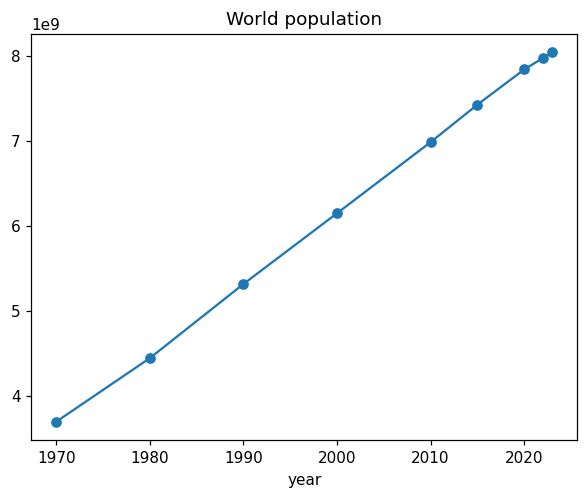

In [24]:
x = [int(i[:4]) for i in years]
plt.plot(x, world.values, marker='o')
plt.title('World population')
plt.xlabel('year')
plt.show()

## More plots

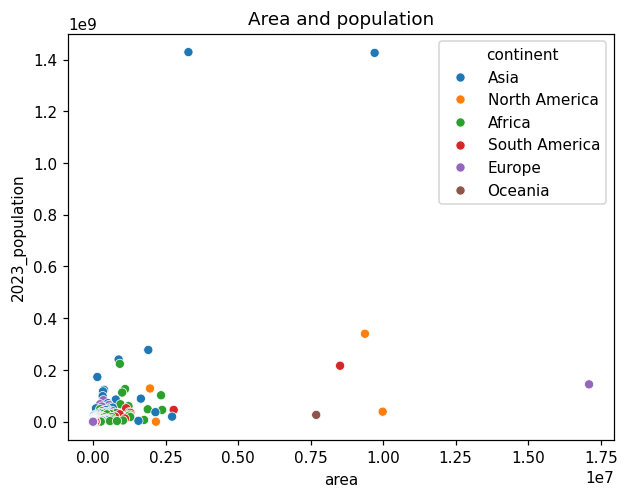

In [25]:
sns.scatterplot(data=df, x='area', y='2023_population', hue='continent')
plt.title('Area and population')
plt.show()

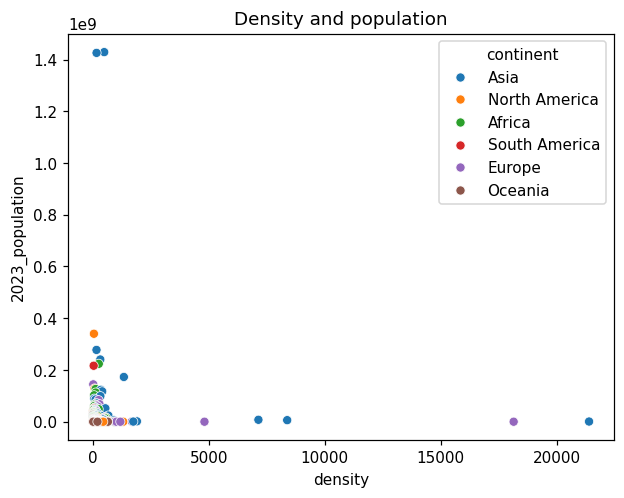

In [26]:
sns.scatterplot(data=df, x='density', y='2023_population', hue='continent')
plt.title('Density and population')
plt.show()

## Correlation

In [27]:
num = ['rank', '2023_population', 'area', 'density', 'growth_rate', 'world_percentage', 'change_since_1970', 'growth_since_1970']
df[num].corr().round(2)

,rank,2023_population,area,density,growth_rate,world_percentage,change_since_1970,growth_since_1970
rank,1.00,-0.36,-0.38,0.13,-0.23,-0.36,-0.36,-0.08
2023_population,-0.36,1.00,0.45,-0.03,-0.02,1.00,0.98,-0.02
area,-0.38,0.45,1.00,-0.07,-0.01,0.45,0.38,-0.04
density,0.13,-0.03,-0.07,1.00,-0.07,-0.03,-0.03,-0.03
growth_rate,-0.23,-0.02,-0.01,-0.07,1.00,-0.02,0.05,0.31
world_percentage,-0.36,1.00,0.45,-0.03,-0.02,1.00,0.98,-0.02
change_since_1970,-0.36,0.98,0.38,-0.03,0.05,0.98,1.00,0.01
growth_since_1970,-0.08,-0.02,-0.04,-0.03,0.31,-0.02,0.01,1.00


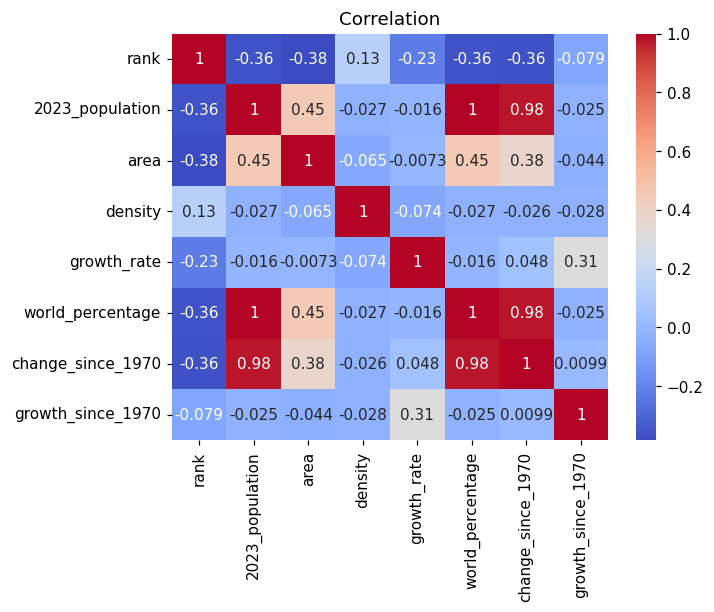

In [28]:
sns.heatmap(df[num].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation')
plt.show()

## Notes

- Asia is the biggest continent by population.
- India and China dominate the top of the table.
- Many of the fastest growing countries are in Africa.
- Density and total population are different things, so small countries can be very dense.

In [29]:
df.to_csv('world_population_cleaned.csv', index=False)